# SIR + SEIR - COVID

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# SIR: new cases

In [22]:
def sir_model(y, t, beta, gamma, N):
    S, I, R = y # current counts of suceptible, infected, recovered
    dSdt = -beta * S * I / N # change of suceptible wrt change in time
    dIdt = beta * S * I / N - gamma * I # change of infected wrt change in time
    dRdt = gamma * I # change in recovered wrt change in time
    return dSdt, dIdt, dRdt # return change of states

In [23]:
def simulate_sir(S0, I0, R0, t, beta, gamma, N):
    '''
    INPUT:
    S0, I0, R0 = The initial counts of susceptible, infected, and recovered individuals.
    t = An array or list of time points at which to evaluate the model
    beta = transmision rate of disease
    gamma = recovery rate of disease
    N = population
    OUTPUT:
    result = array where each row corresponds to a time point and the columns represent the values of S, I, and R respectively
    '''
    y0 = (S0, I0, R0) 
    result = odeint(sir_model, y0, t, args=(beta, gamma, N)) # use odeint to solve the differential equations defined in sir_model
    # derivate at each t in the time_vector to give the paths of S,I,R
    S, I, R = result.T
    return S, I, R

In [24]:
df = pd.read_csv('../Data/silver/covid_data_weekly.csv')  
data = df[df['country']=='Chile']
data = data[data['new_cases'] > 0].reset_index(drop=True)
t_data = np.arange(1, len(data)+1)
I_data = data['new_cases'].values
N = 40_000_000  # Replace with the actual population size

In [25]:
# initial conditions
I0 = I_data[0] # infected
S0 = N - I0 # suceptible
R0 = 0 # recovered / death

In [26]:
# fit function
def fit_function(t, beta, gamma):
    S, I, R = simulate_sir(S0, I0, R0, t, beta, gamma, N)
    return I

In [27]:
beta_guess = 0.5  # Initial guess for transmission rate
gamma_guess = 0.3  # Initial guess for recovery rate
initial_guess = [beta_guess, gamma_guess]

popt, pcov = curve_fit(fit_function, t_data, I_data, p0=initial_guess)
beta_opt, gamma_opt = popt

In [28]:
t_sim = np.linspace(0, t_data[-1], 100)  # Time points for simulation
S_opt, I_opt, R_opt = simulate_sir(S0, I0, R0, t_sim, beta_opt, gamma_opt, N)

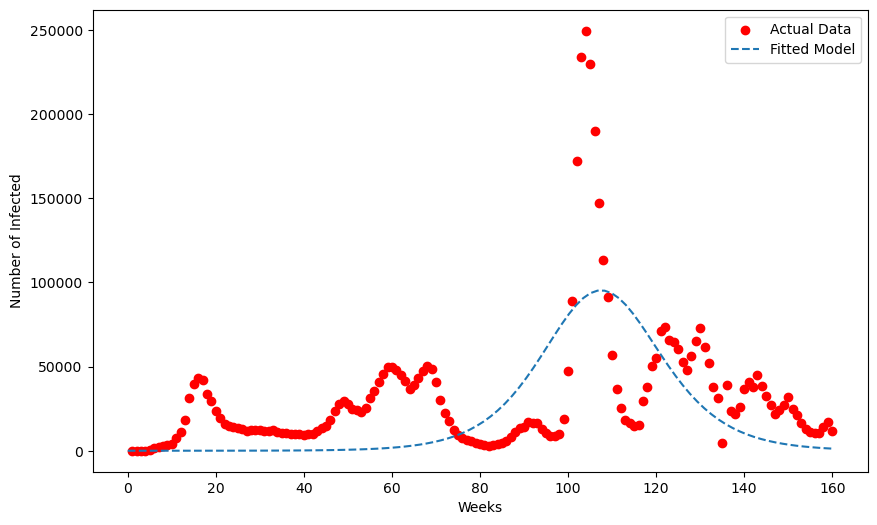

Optimized beta: 1.6624976016618682
Optimized gamma: 1.5490565086177401
Basic Reproduction Number R0: 1.0732323788144786


In [29]:
plt.figure(figsize=(10, 6))
plt.scatter(t_data, I_data, label='Actual Data', color='red')
plt.plot(t_sim, I_opt, label='Fitted Model', linestyle='dashed')
plt.xlabel('Weeks')
plt.ylabel('Number of Infected')
plt.legend()
plt.show()

print(f"Optimized beta: {beta_opt}")
print(f"Optimized gamma: {gamma_opt}")
print(f"Basic Reproduction Number R0: {beta_opt / gamma_opt}")

# SIR Cumulative

In [30]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

In [31]:
# SIR model equations
def sir_model(y, t, beta, gamma, N):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return dSdt, dIdt, dRdt

# Simulate cumulative SIR cases
def simulate_sir(S0, I0, R0, t, beta, gamma, N):
    y0 = (S0, I0, R0)
    result = odeint(sir_model, y0, t, args=(beta, gamma, N))
    S, I, R = result.T
    cumulative = N - S
    return cumulative

# Fit function for curve fitting
def fit_function(t, beta, gamma):
    return simulate_sir(S0, I0, R0, t, beta, gamma, N)

In [32]:
country_pop_dict = {'Brazil': 208126926,
 'Chile': 19331414,
 'Colombia': 50326931,
 'Dominican Republic': 10948573,
 'Germany': 83634807,
 'Italy': 60041302,
 'Mexico': 126356930,
 'Panama': 4267228,
 'US': 339142428,
 'Uruguay': 3397691}

## All countries

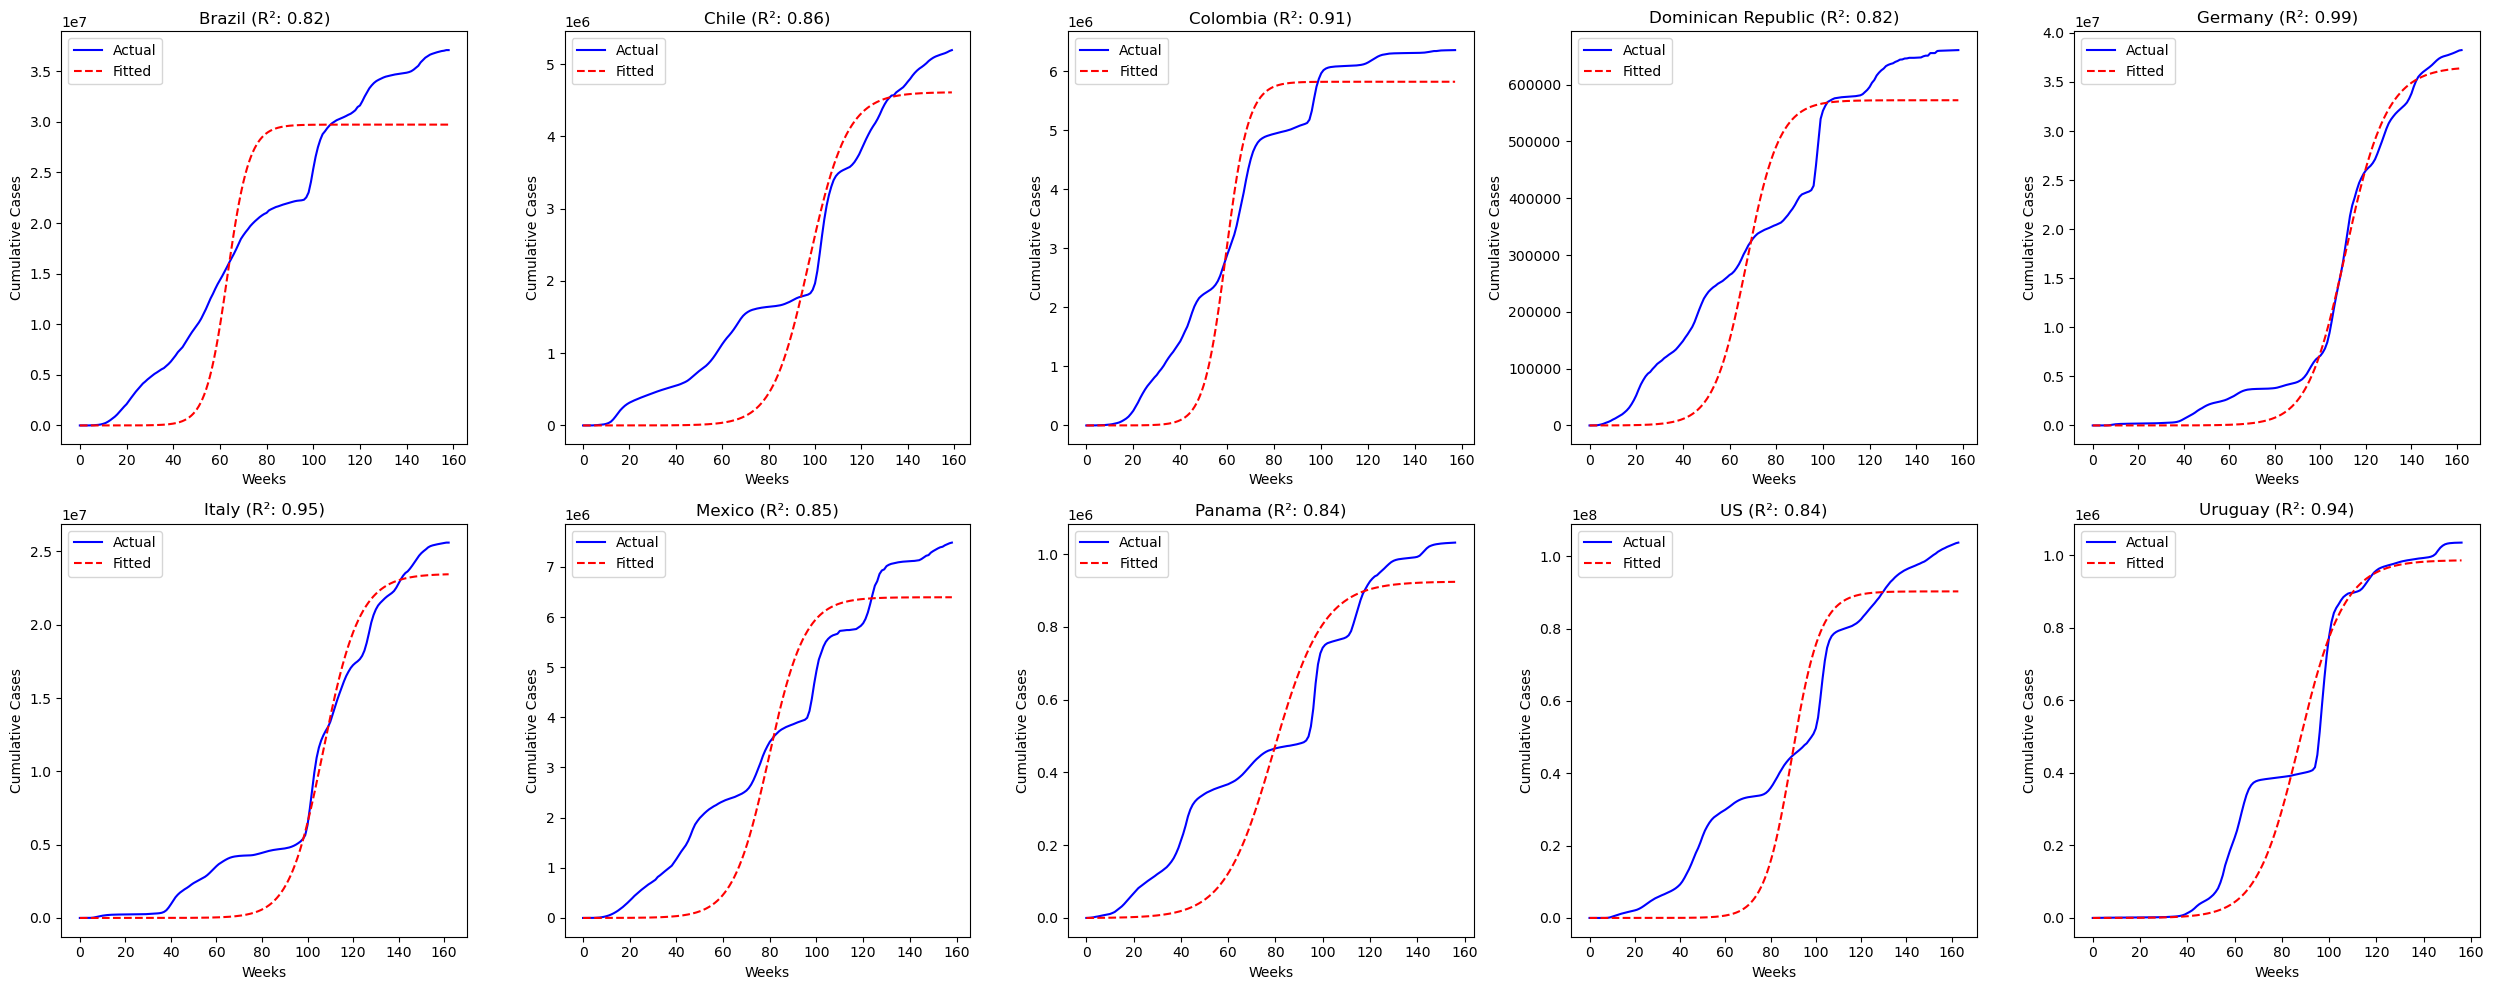

In [33]:
fig, axes = plt.subplots(2, 5, figsize=(25, 10), sharex=False, sharey=False)
axes = axes.flatten()
evaluation_metrics = {}

for idx, country in enumerate(list(country_pop_dict.keys())[:10]):
    # Filter data for country
    data = df[df['country'] == country].copy()
    data = data[data['cases'] > 0].reset_index(drop=True)

    # Prepare data
    t_data = np.arange(len(data))
    C_data = np.cumsum(data['new_cases'].values)
    N = country_pop_dict[country]

    # Initial conditions (first week of cumulative cases)
    I0 = C_data[0]
    R0 = 0
    S0 = N - I0 - R0

    # Initial parameter guesses (weekly scale)
    initial_guess = [0.5, 0.3]  # Adjust if necessary

    # Curve fitting
    popt, pcov = curve_fit(fit_function, t_data, C_data, p0=initial_guess, bounds=(0, np.inf))
    beta_opt, gamma_opt = popt

    # Simulate optimal model
    t_sim = np.linspace(0, len(t_data)-1, len(t_data)*10)
    cumulative_sim = simulate_sir(S0, I0, R0, t_sim, beta_opt, gamma_opt, N)

    # Evaluate metrics at actual data points
    cumulative_pred = simulate_sir(S0, I0, R0, t_data, beta_opt, gamma_opt, N)
    rmse = np.sqrt(mean_squared_error(C_data, cumulative_pred))
    r2 = r2_score(C_data, cumulative_pred)
    evaluation_metrics[country] = {'RMSE': rmse, 'R2': r2, 'beta': beta_opt, 'gamma': gamma_opt, 'R0': beta_opt/gamma_opt}

    # Plot
    ax = axes[idx]
    ax.plot(t_data, C_data, label='Actual', color='blue')
    ax.plot(t_sim, cumulative_sim, label='Fitted', color='red', linestyle='--')
    ax.set_title(f'{country} (R²: {r2:.2f})')
    ax.set_xlabel('Weeks')
    ax.set_ylabel('Cumulative Cases')
    ax.legend()

plt.tight_layout()
plt.show()

In [34]:
# Display evaluation metrics
metrics_df = pd.DataFrame.from_dict(evaluation_metrics, orient='index')
metrics_df

,RMSE,R2,beta,gamma,R0
Brazil,5.304687e+06,0.824985,3.006812,2.786621,1.079017
Chile,6.559192e+05,0.859297,1.036654,0.907430,1.142407
Colombia,7.105782e+05,0.912618,3.637491,3.422747,1.062740
Dominican Republic,9.643134e+04,0.823907,5.430377,5.287131,1.027093
Germany,1.708265e+06,0.985185,0.515338,0.391887,1.315016
Italy,2.103317e+06,0.946831,0.652346,0.514308,1.268396
Mexico,9.947630e+05,0.849437,5.124999,4.994210,1.026188
Panama,1.406337e+05,0.839753,0.875854,0.777129,1.127037
US,1.474916e+07,0.837213,1.197825,1.030120,1.162802
Uruguay,9.712494e+04,0.943608,0.736578,0.623591,1.181189


In [35]:
metrics_df[['R2', 'RMSE']]

,R2,RMSE
Brazil,0.824985,5.304687e+06
Chile,0.859297,6.559192e+05
Colombia,0.912618,7.105782e+05
Dominican Republic,0.823907,9.643134e+04
Germany,0.985185,1.708265e+06
Italy,0.946831,2.103317e+06
Mexico,0.849437,9.947630e+05
Panama,0.839753,1.406337e+05
US,0.837213,1.474916e+07
Uruguay,0.943608,9.712494e+04


## Train-Test Split

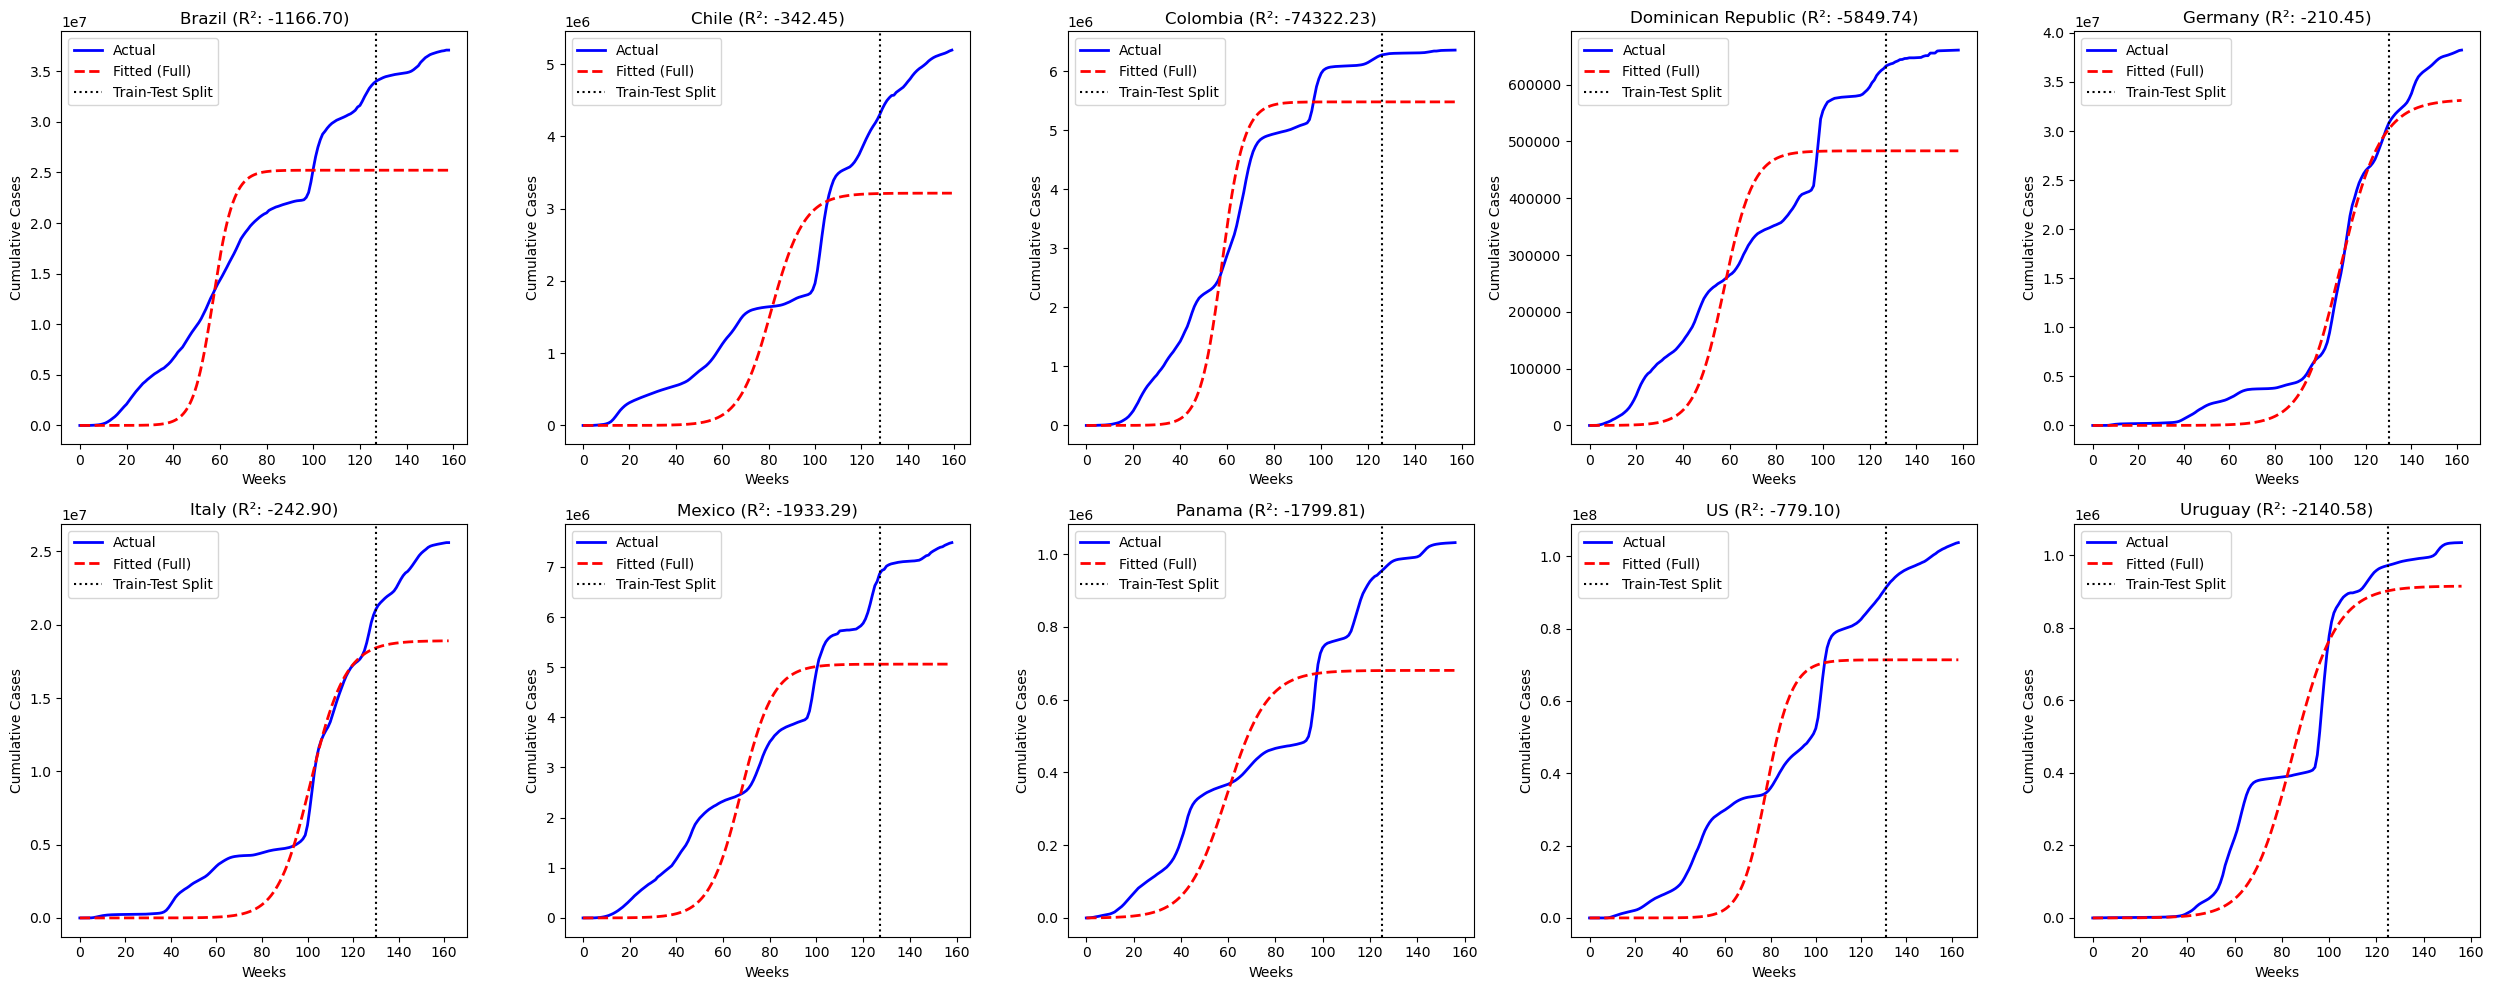

In [36]:
fig, axes = plt.subplots(2, 5, figsize=(25, 10), sharex=False, sharey=False)
axes = axes.flatten()
evaluation_metrics = {}

for idx, country in enumerate(list(country_pop_dict.keys())[:10]):
    # Filter data for country
    data = df[df['country'] == country].copy()
    data = data[data['cases'] > 0].reset_index(drop=True)

    # Prepare data
    t_data = np.arange(len(data))
    C_data = np.cumsum(data['new_cases'].values)
    N = country_pop_dict[country]

    # 80-20 Train-Test Split
    split_index = int(len(data) * 0.8)
    t_train, t_test = t_data[:split_index], t_data[split_index:]
    C_train, C_test = C_data[:split_index], C_data[split_index:]

    # Initial conditions
    I0 = C_train[0]  # Infected at the start of training
    R0 = 0
    S0 = N - I0 - R0

    # Initial parameter guesses
    initial_guess = [0.5, 0.3]  # Adjust if necessary

    # Curve fitting using only training data
    popt, pcov = curve_fit(fit_function, t_train, C_train, p0=initial_guess, bounds=(0, np.inf))
    beta_opt, gamma_opt = popt

    # Simulate optimal model over the full time range
    t_sim = np.linspace(0, len(t_data)-1, len(t_data) * 10)
    cumulative_sim = simulate_sir(S0, I0, R0, t_sim, beta_opt, gamma_opt, N)

    # Predictions for training and test sets
    C_pred_train = simulate_sir(S0, I0, R0, t_train, beta_opt, gamma_opt, N)
    C_pred_test = simulate_sir(S0, I0, R0, t_test, beta_opt, gamma_opt, N)

    # Evaluate metrics on the test set
    rmse = np.sqrt(mean_squared_error(C_test, C_pred_test))
    r2 = r2_score(C_test, C_pred_test)

    evaluation_metrics[country] = {
        'RMSE': rmse, 'R2': r2, 'beta': beta_opt, 'gamma': gamma_opt, 'R0': beta_opt/gamma_opt
    }

    # Plot
    ax = axes[idx]
    ax.plot(t_data, C_data, label='Actual', color='blue', linewidth=2)
    ax.plot(t_sim, cumulative_sim, label='Fitted (Full)', color='red', linestyle='--', linewidth=2)
    ax.axvline(x=split_index, color='black', linestyle=':', label='Train-Test Split')
    
    ax.set_title(f'{country} (R²: {r2:.2f})')
    ax.set_xlabel('Weeks')
    ax.set_ylabel('Cumulative Cases')
    ax.legend()

plt.tight_layout()
plt.show()

In [37]:
# get a dataframe from evauluation_metrics
metrics_df_split = pd.DataFrame.from_dict(evaluation_metrics, orient='index')
metrics_df_split

,RMSE,R2,beta,gamma,R0
Brazil,3.551820e+07,-1166.697040,3.840802,3.603139,1.065960
Chile,4.850543e+06,-342.446760,1.705612,1.559565,1.093646
Colombia,6.319862e+06,-74322.225143,3.947548,3.728430,1.058769
Dominican Republic,6.489750e+05,-5849.742776,7.243589,7.082476,1.022748
Germany,3.546505e+07,-210.450650,0.576565,0.452373,1.274535
Italy,2.386507e+07,-242.904926,0.842913,0.701803,1.201067
Mexico,7.179580e+06,-1933.290987,7.265935,7.119459,1.020574
Panama,9.967371e+05,-1799.814133,1.473674,1.352853,1.089309
US,9.851936e+07,-779.103622,1.699055,1.513193,1.122828
Uruguay,1.000999e+06,-2140.578501,0.811527,0.696600,1.164983


In [38]:
metrics_df_split_params = metrics_df_split[['beta', 'gamma', 'R0']]
latex_table = metrics_df_split_params.to_latex(
    index=True,                 # False if you *don’t* want the index column
    caption="Parameters for each country",
    label="tab:metrics",
    float_format="%.3f",        # formats floats to 3 decimals
    column_format="lrrr",      # LaTeX tabular spec: 1 left-, 4 right-aligned cols
    longtable=False,            # True if you need multipage tables
    bold_rows=True              # makes the index bold; can omit
)

print(latex_table)              # inspect or copy-paste

\begin{table}
\caption{Parameters for each country}
\label{tab:metrics}
\begin{tabular}{lrrr}
\toprule
 & beta & gamma & R0 \\
\midrule
\textbf{Brazil} & 3.841 & 3.603 & 1.066 \\
\textbf{Chile} & 1.706 & 1.560 & 1.094 \\
\textbf{Colombia} & 3.948 & 3.728 & 1.059 \\
\textbf{Dominican Republic} & 7.244 & 7.082 & 1.023 \\
\textbf{Germany} & 0.577 & 0.452 & 1.275 \\
\textbf{Italy} & 0.843 & 0.702 & 1.201 \\
\textbf{Mexico} & 7.266 & 7.119 & 1.021 \\
\textbf{Panama} & 1.474 & 1.353 & 1.089 \\
\textbf{US} & 1.699 & 1.513 & 1.123 \\
\textbf{Uruguay} & 0.812 & 0.697 & 1.165 \\
\bottomrule
\end{tabular}
\end{table}



In [39]:
metrics_df_split[['R2', 'RMSE']]

,R2,RMSE
Brazil,-1166.697040,3.551820e+07
Chile,-342.446760,4.850543e+06
Colombia,-74322.225143,6.319862e+06
Dominican Republic,-5849.742776,6.489750e+05
Germany,-210.450650,3.546505e+07
Italy,-242.904926,2.386507e+07
Mexico,-1933.290987,7.179580e+06
Panama,-1799.814133,9.967371e+05
US,-779.103622,9.851936e+07
Uruguay,-2140.578501,1.000999e+06


### Save CSV

In [40]:
# First, determine the maximum length
max_len = 0
country_fitted_values = {}

countries = list(country_pop_dict.keys())[:10]

# Calculate the maximum length
for country in countries:
    data = df[(df['country'] == country) & (df['cases'] > 0)].copy()
    length = len(data)
    max_len = max(max_len, length)

# Initialize DataFrame
fitted_df = pd.DataFrame({'time': np.arange(max_len)})

# Compute fitted values and align them at the tail
for country in countries:
    data = df[(df['country'] == country) & (df['cases'] > 0)].copy().reset_index(drop=True)

    if data.empty:
        fitted_df[country] = np.nan
        continue

    t_data = np.arange(len(data))
    C_data = np.cumsum(data['new_cases'].values)
    N = country_pop_dict[country]

    split_index = int(len(data) * 0.8)
    t_train = t_data[:split_index]
    C_train = C_data[:split_index]

    I0 = C_train[0]
    R0 = 0
    S0 = N - I0 - R0

    initial_guess = [0.5, 0.3]
    try:
        popt, _ = curve_fit(fit_function, t_train, C_train, p0=initial_guess, bounds=(0, np.inf))
        beta_opt, gamma_opt = popt
        C_fitted = simulate_sir(S0, I0, R0, t_data, beta_opt, gamma_opt, N)
    except Exception as e:
        print(f"Curve fitting failed for {country}: {e}")
        C_fitted = np.full(len(t_data), np.nan)

    # Align at tail: Pad beginning with 0
    pad_size = max_len - len(C_fitted)
    if pad_size > 0:
        C_fitted_aligned = np.pad(C_fitted, (pad_size, 0), constant_values=0)
    else:
        C_fitted_aligned = C_fitted

    fitted_df[country] = C_fitted_aligned



In [41]:
# convert all columns to int
fitted_df.iloc[:, 1:] = fitted_df.iloc[:, 1:].fillna(0).astype(int)

In [42]:
fitted_df.to_csv('../results/SIR_covid.csv', index=False)

# SEIR

**Definition of SEIR**
Model has:
* *S* Suceptible individuals
* *E* exposed individuals (not yet infectious)
* *I* infectious* individuals
* *R* recovered individuals

Model is described by set of differential equations:

$$
\begin{aligned}
\dot{S} &= -\beta \frac{SI}{N} \\
\dot{E} &= \beta \frac{SI}{N} - \sigma E \\
\dot{I} &= \sigma E  - \gamma I \\
\dot{R} &=  \gamma I
\end{aligned}
$$

With:
* $\beta$ transmision rate
* $\sigma$ incubation rate (1/inucbation period)
* $\gamma$ recovery rate (1/infectious period )
* *N* total popualtion

In [43]:
# Define SEIR equations
def seir_model(y, t, beta, gamma, sigma, N):
    S, E, I, R = y
    dSdt = -beta * S * I / N
    dEdt = beta * S * I / N - sigma * E
    dIdt = sigma * E - gamma * I
    dRdt = gamma * I
    return dSdt, dEdt, dIdt, dRdt

# Simulate and return cumulative cases
def simulate_seir(S0, E0, I0, R0, t, beta, gamma, sigma, N):
    y0 = (S0, E0, I0, R0)
    result = odeint(seir_model, y0, t, args=(beta, gamma, sigma, N))
    S, E, I, R = result.T
    cumulative = N - S  # Cumulative cases = N - S(t)
    return cumulative, I, R

# Fit function for curve_fit; extra parameters are passed in via a lambda below.
def fit_function_seir(t, beta, gamma, sigma, N, S0, E0, I0, R0):
    cumulative, _, _ = simulate_seir(S0, E0, I0, R0, t, beta, gamma, sigma, N)
    return cumulative

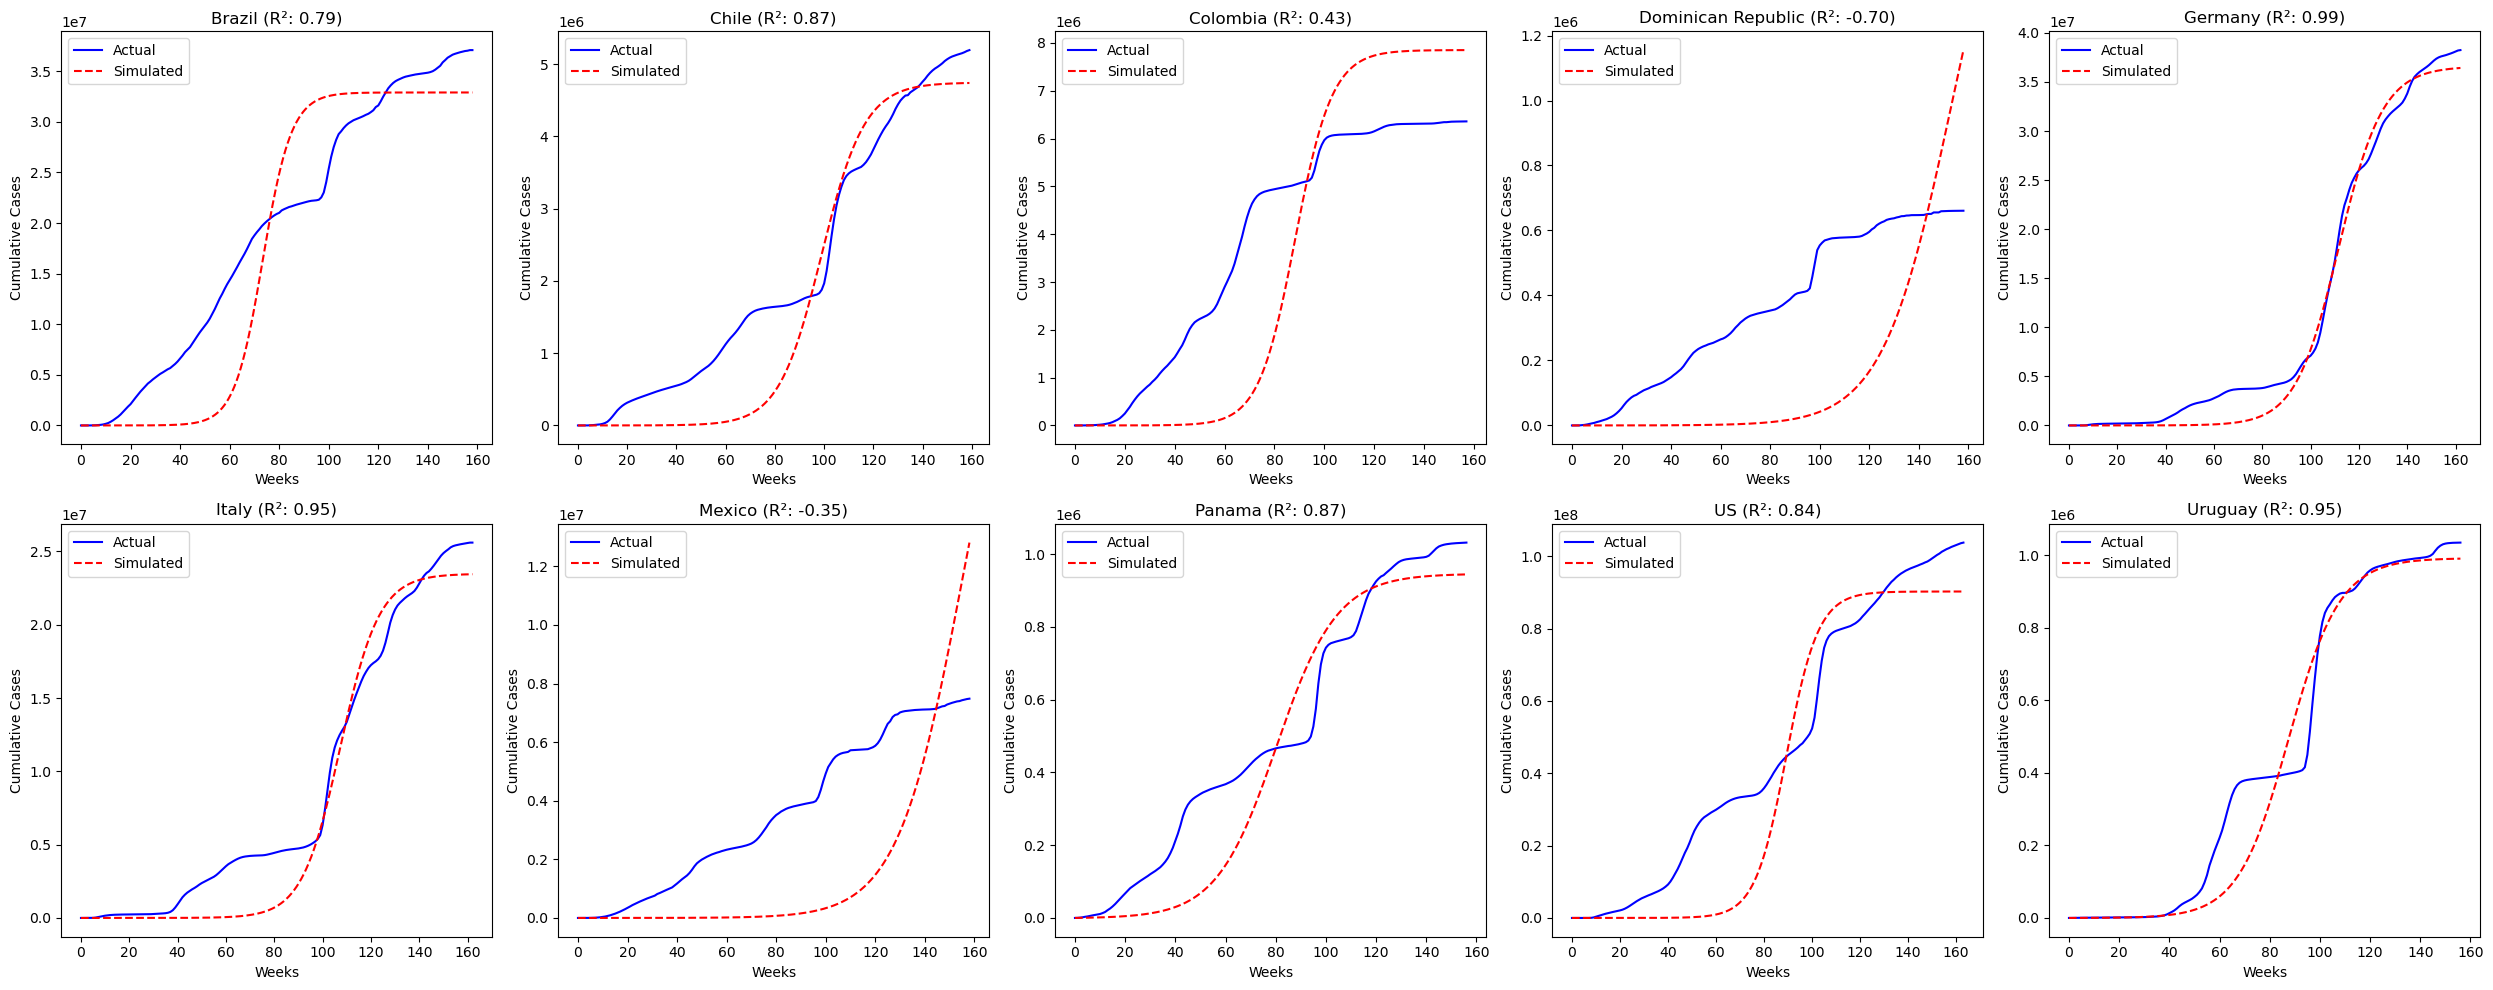

In [44]:
# Assume df and country_pop_dict are already loaded and defined
fig, axes = plt.subplots(2, 5, figsize=(25, 10), sharex=False, sharey=False)
axes = axes.flatten()
evaluation_metrics_seir = {}

for idx, country in enumerate(list(country_pop_dict.keys())[:10]):
    data = df[df['country'] == country].copy()
    data = data[data['cases'] > 0].reset_index(drop=True)

    t_data = np.arange(len(data))
    C_data = np.cumsum(data['new_cases'].values)
    N = country_pop_dict[country]

    # Initial conditions
    I0 = C_data[0]
    E0 = I0 * 2
    R0 = 0
    S0 = N - I0 - E0 - R0

    # Initial parameter guesses
    initial_guess = [1.0, 0.5, 0.5]

    # Fit the model using lambda to pass fixed parameters
    popt, pcov = curve_fit(
        lambda t, beta, gamma, sigma: fit_function_seir(t, beta, gamma, sigma, N, S0, E0, I0, R0),
        t_data,
        C_data,
        p0=initial_guess,
        bounds=(0, np.inf)
    )

    beta_opt, gamma_opt, sigma_opt = popt

    # Simulate with optimized parameters
    t_sim = np.linspace(0, len(t_data)-1, len(t_data)*10)
    cumulative_sim, _, _ = simulate_seir(S0, E0, I0, R0, t_sim, beta_opt, gamma_opt, sigma_opt, N)

    # Metrics
    cumulative_pred, _, _ = simulate_seir(S0, E0, I0, R0, t_data, beta_opt, gamma_opt, sigma_opt, N)
    rmse = np.sqrt(mean_squared_error(C_data, cumulative_pred))
    r2 = r2_score(C_data, cumulative_pred)

    evaluation_metrics_seir[country] = {
        'RMSE': rmse,
        'R2': r2,
        'beta': beta_opt,
        'gamma': gamma_opt,
        'sigma': sigma_opt,
        'R0': beta_opt / gamma_opt
    }

    # Plot
    ax = axes[idx]
    ax.plot(t_data, C_data, label='Actual', color='blue')
    ax.plot(t_sim, cumulative_sim, label='Simulated', linestyle='--', color='red')
    ax.set_title(f'{country} (R²: {r2:.2f})')
    ax.set_xlabel('Weeks')
    ax.set_ylabel('Cumulative Cases')
    ax.legend()

plt.tight_layout()
plt.show()


In [45]:
# Display evaluation metrics
metrics_seir_df = pd.DataFrame.from_dict(evaluation_metrics_seir, orient='index')
metrics_seir_df

,RMSE,R2,beta,gamma,sigma,R0
Brazil,5.752140e+06,0.794214,2.354427,2.163031,30.015733,1.088485
Chile,6.342785e+05,0.868428,1.184970,1.032790,3.798494,1.147349
Colombia,1.813809e+06,0.430644,1.794633,1.650697,49.970760,1.087197
Dominican Republic,3.000313e+05,-0.704662,1.209698,1.096699,2.060799,1.103035
Germany,1.646926e+06,0.986229,1.261769,0.959441,0.638289,1.315108
Italy,2.056768e+06,0.949159,1.096200,0.864252,1.203895,1.268381
Mexico,2.976087e+06,-0.347625,1.226783,1.110487,2.307702,1.104726
Panama,1.283886e+05,0.866444,1.072498,0.948741,2.191988,1.130444
US,1.440751e+07,0.844667,1.377179,1.184438,5.625407,1.162728
Uruguay,8.965920e+04,0.951944,0.941415,0.796194,2.008768,1.182394


In [46]:
metrics_seir_df[['R2', 'RMSE']]

,R2,RMSE
Brazil,0.794214,5.752140e+06
Chile,0.868428,6.342785e+05
Colombia,0.430644,1.813809e+06
Dominican Republic,-0.704662,3.000313e+05
Germany,0.986229,1.646926e+06
Italy,0.949159,2.056768e+06
Mexico,-0.347625,2.976087e+06
Panama,0.866444,1.283886e+05
US,0.844667,1.440751e+07
Uruguay,0.951944,8.965920e+04


## Train-Test Split

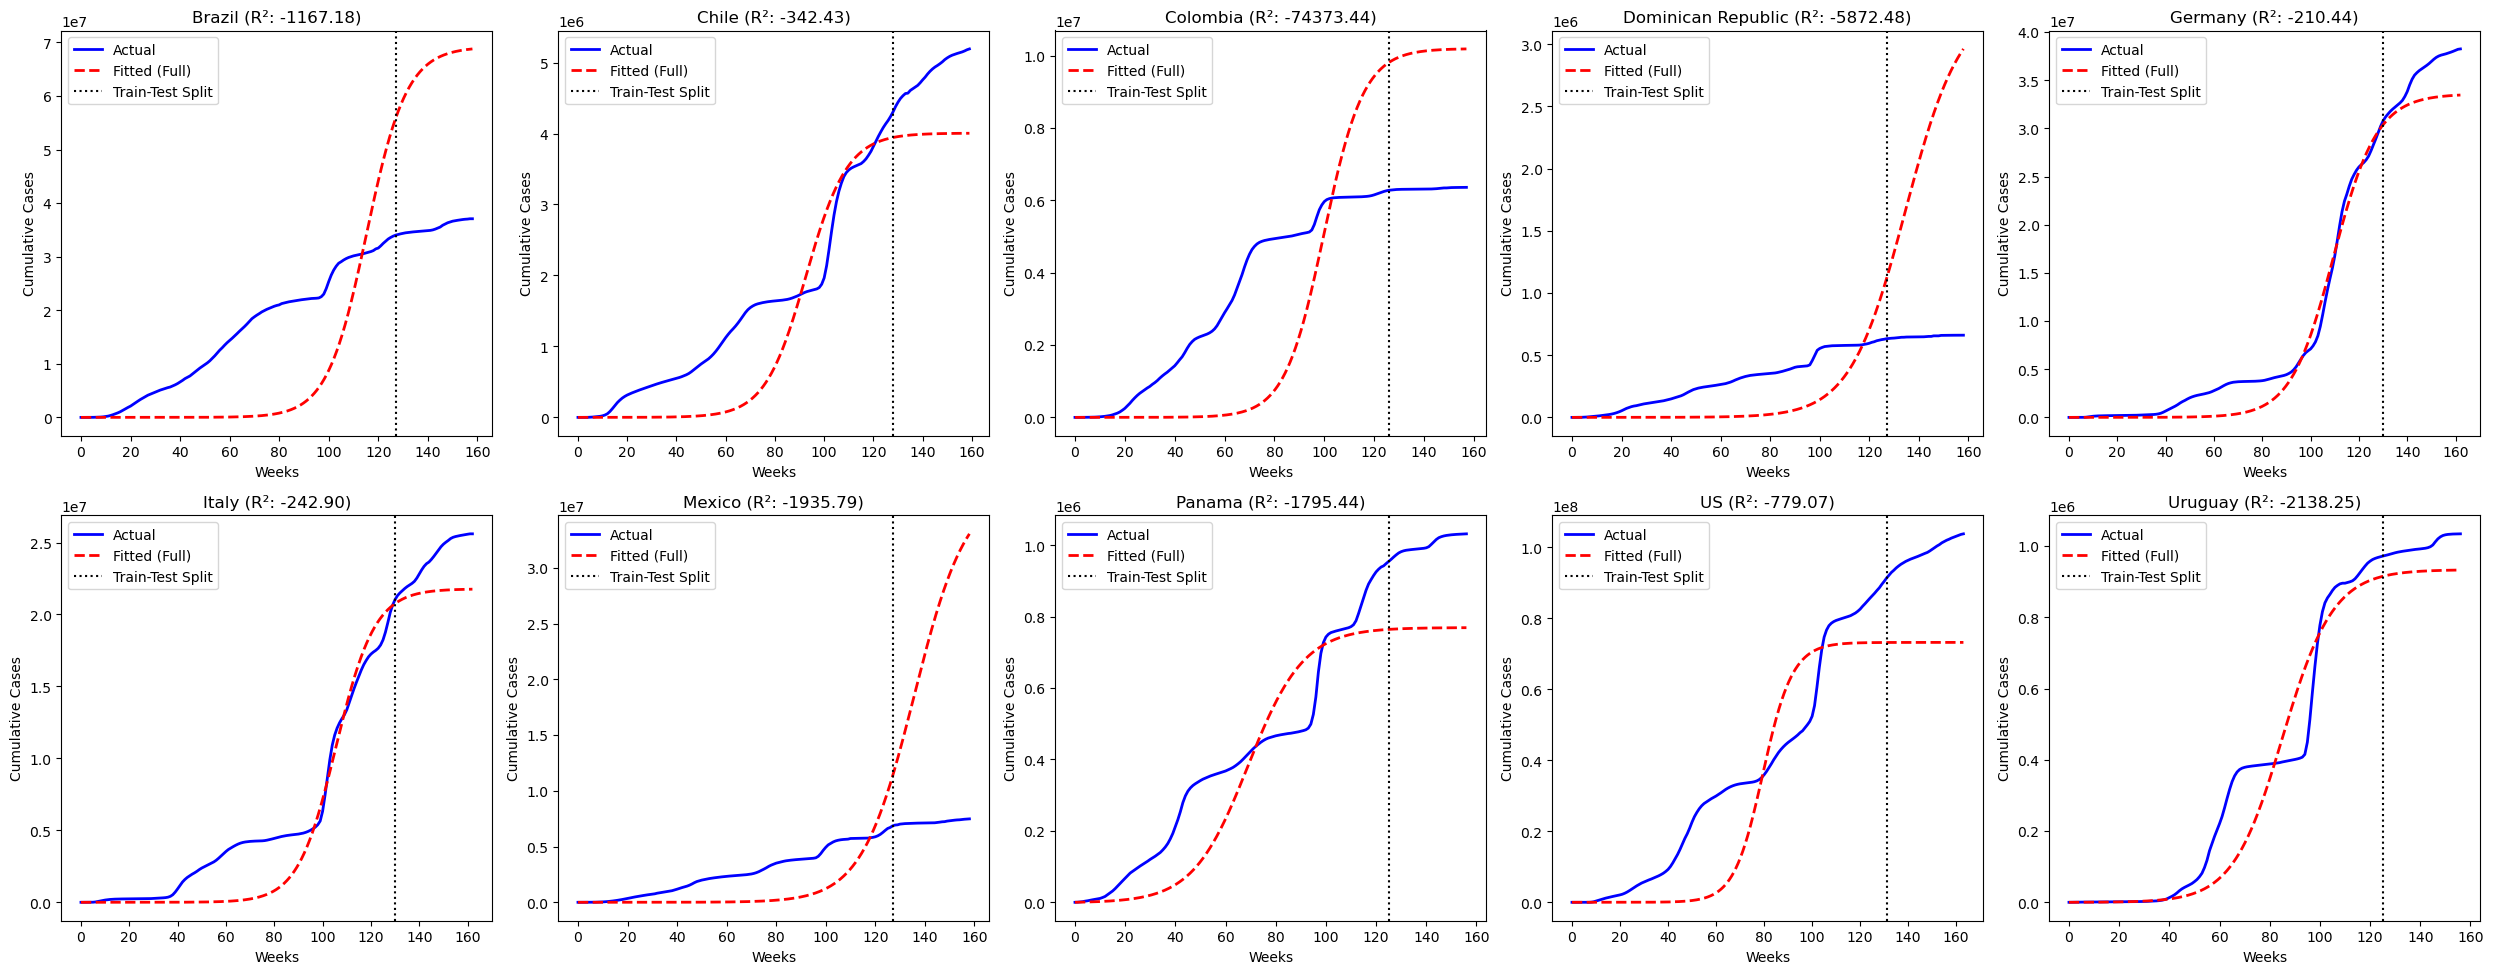

In [47]:
fig, axes = plt.subplots(2, 5, figsize=(25, 10), sharex=False, sharey=False)
axes = axes.flatten()
evaluation_metrics_seir = {}

for idx, country in enumerate(list(country_pop_dict.keys())[:10]):
    data = df[df['country'] == country].copy()
    data = data[data['cases'] > 0].reset_index(drop=True)

    # Prepare time and cumulative case data
    t_data = np.arange(len(data))
    C_data = np.cumsum(data['new_cases'].values)
    N = country_pop_dict[country]

    # Train-test split (80-20)
    split_index = int(len(data) * 0.8)
    t_train, t_test = t_data[:split_index], t_data[split_index:]
    C_train, C_test = C_data[:split_index], C_data[split_index:]

    # Initial conditions
    I0 = C_train[0]  # Initial infected
    E0 = I0 * 2  # Assume twice the initial exposed
    R0 = 0
    S0 = N - I0 - E0 - R0

    # Initial parameter guesses
    initial_guess = [1.0, 0.5, 0.5]

    # Fit the model using training data
    popt, pcov = curve_fit(
        lambda t, beta, gamma, sigma: fit_function_seir(t, beta, gamma, sigma, N, S0, E0, I0, R0),
        t_train,
        C_train,
        p0=initial_guess,
        bounds=(0, np.inf)
    )

    beta_opt, gamma_opt, sigma_opt = popt

    # Simulate the fitted model over the full time range
    t_sim = np.linspace(0, len(t_data) - 1, len(t_data) * 10)
    cumulative_sim, _, _ = simulate_seir(S0, E0, I0, R0, t_sim, beta_opt, gamma_opt, sigma_opt, N)

    # Predictions for training and test sets
    C_pred_train, _, _ = simulate_seir(S0, E0, I0, R0, t_train, beta_opt, gamma_opt, sigma_opt, N)
    C_pred_test, _, _ = simulate_seir(S0, E0, I0, R0, t_test, beta_opt, gamma_opt, sigma_opt, N)

    # Evaluate metrics on test set
    rmse = np.sqrt(mean_squared_error(C_test, C_pred_test))
    r2 = r2_score(C_test, C_pred_test)

    evaluation_metrics_seir[country] = {
        'RMSE': rmse,
        'R2': r2,
        'beta': beta_opt,
        'gamma': gamma_opt,
        'sigma': sigma_opt,
        'R0': beta_opt / gamma_opt
    }

    # Plot results
    ax = axes[idx]
    ax.plot(t_data, C_data, label='Actual', color='blue', linewidth=2)
    ax.plot(t_sim, cumulative_sim, label='Fitted (Full)', linestyle='--', color='red', linewidth=2)
    ax.axvline(x=split_index, color='black', linestyle=':', label='Train-Test Split')

    ax.set_title(f'{country} (R²: {r2:.2f})')
    ax.set_xlabel('Weeks')
    ax.set_ylabel('Cumulative Cases')
    ax.legend()

plt.tight_layout()
plt.show()


In [48]:
# get a dataframe from evauluation_metrics
metrics_df_split_seir = pd.DataFrame.from_dict(evaluation_metrics_seir, orient='index')
metrics_df_split_seir

,RMSE,R2,beta,gamma,sigma,R0
Brazil,3.552559e+07,-1167.182567,1.190164,0.979124,1.645701,1.215540
Chile,4.850431e+06,-342.430937,1.625815,1.450877,3.521602,1.120574
Colombia,6.322039e+06,-74373.441279,1.623605,1.452968,4.785170,1.117440
Dominican Republic,6.502348e+05,-5872.479075,1.146283,0.960774,0.991076,1.193083
Germany,3.546430e+07,-210.441691,1.188922,0.930002,0.814013,1.278408
Italy,2.386488e+07,-242.900953,1.100035,0.885597,1.497048,1.242140
Mexico,7.184214e+06,-1935.788642,1.167195,0.985321,1.180639,1.184584
Panama,9.955245e+05,-1795.435129,1.338025,1.213608,3.643112,1.102518
US,9.851718e+07,-779.069108,1.584575,1.406596,30.999150,1.126531
Uruguay,1.000455e+06,-2138.251023,0.946462,0.809486,2.630020,1.169212


In [49]:
metrics_df_split_seir_params = metrics_df_split_seir[['beta', 'gamma','sigma', 'R0']]
latex_table = metrics_df_split_seir_params.to_latex(
    index=True,                 # False if you *don’t* want the index column
    caption="Parameters for each country",
    label="tab:metrics",
    float_format="%.3f",        # formats floats to 3 decimals
    column_format="lrrr",      # LaTeX tabular spec: 1 left-, 4 right-aligned cols
    longtable=False,            # True if you need multipage tables
    bold_rows=True              # makes the index bold; can omit
)

print(latex_table)   

\begin{table}
\caption{Parameters for each country}
\label{tab:metrics}
\begin{tabular}{lrrr}
\toprule
 & beta & gamma & sigma & R0 \\
\midrule
\textbf{Brazil} & 1.190 & 0.979 & 1.646 & 1.216 \\
\textbf{Chile} & 1.626 & 1.451 & 3.522 & 1.121 \\
\textbf{Colombia} & 1.624 & 1.453 & 4.785 & 1.117 \\
\textbf{Dominican Republic} & 1.146 & 0.961 & 0.991 & 1.193 \\
\textbf{Germany} & 1.189 & 0.930 & 0.814 & 1.278 \\
\textbf{Italy} & 1.100 & 0.886 & 1.497 & 1.242 \\
\textbf{Mexico} & 1.167 & 0.985 & 1.181 & 1.185 \\
\textbf{Panama} & 1.338 & 1.214 & 3.643 & 1.103 \\
\textbf{US} & 1.585 & 1.407 & 30.999 & 1.127 \\
\textbf{Uruguay} & 0.946 & 0.809 & 2.630 & 1.169 \\
\bottomrule
\end{tabular}
\end{table}



In [82]:
metrics_df_split_seir[['R2', 'RMSE']]

,R2,RMSE
Brazil,-1167.718088,3.552542e+07
Chile,-342.430937,4.850431e+06
Colombia,-74373.441279,6.322039e+06
Dominican Republic,-5872.479075,6.502348e+05
Germany,-210.441691,3.546430e+07
Italy,-242.900953,2.386488e+07
Mexico,-1935.788642,7.184214e+06
Panama,-1795.435129,9.955245e+05
US,-779.069108,9.851718e+07
Uruguay,-2138.251023,1.000455e+06


### Save CSV

In [83]:
# Find maximum length across all countries
max_len_seir = 0
countries = list(country_pop_dict.keys())[:10]

for country in countries:
    data = df[(df['country'] == country) & (df['cases'] > 0)].copy()
    max_len_seir = max(max_len_seir, len(data))

# Initialize empty dataframe aligned at the tail
fitted_df_seir = pd.DataFrame({'time': np.arange(max_len_seir)})

for country in countries:
    data = df[(df['country'] == country) & (df['cases'] > 0)].copy().reset_index(drop=True)

    if data.empty:
        fitted_df_seir[country] = np.nan
        continue

    t_data = np.arange(len(data))
    C_data = np.cumsum(data['new_cases'].values)
    N = country_pop_dict[country]

    # Train-test split
    split_index = int(len(data) * 0.8)
    t_train, C_train = t_data[:split_index], C_data[:split_index]

    # Initial conditions
    I0 = C_train[0]
    E0 = I0 * 2
    R0 = 0
    S0 = N - I0 - E0 - R0

    # Curve fitting
    initial_guess = [1.0, 0.5, 0.5]
    try:
        popt, _ = curve_fit(
            lambda t, beta, gamma, sigma: fit_function_seir(t, beta, gamma, sigma, N, S0, E0, I0, R0),
            t_train, C_train,
            p0=initial_guess, bounds=(0, np.inf)
        )
        beta_opt, gamma_opt, sigma_opt = popt

        # Simulate fitted model for the full data range
        C_fitted, _, _ = simulate_seir(S0, E0, I0, R0, t_data, beta_opt, gamma_opt, sigma_opt, N)
    except Exception as e:
        print(f"Curve fitting failed for {country}: {e}")
        C_fitted = np.full(len(t_data), np.nan)

    # Tail-align the series by padding the start
    pad_size = max_len_seir - len(C_fitted)
    if pad_size > 0:
        C_fitted_aligned = np.pad(C_fitted, (pad_size, 0), constant_values=0)
    else:
        C_fitted_aligned = C_fitted

    fitted_df_seir[country] = C_fitted_aligned

In [ ]:
# convert all columns to int
fitted_df_seir.iloc[:, 1:] = fitted_df_seir.iloc[:, 1:].fillna(0).astype(int)

In [ ]:
# save
fitted_df_seir.to_csv('../results/SEIR_covid.csv', index=False)